In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings

In [3]:
warnings.filterwarnings("ignore")

In [4]:
import anndata as ad
import scanpy as sc
from matplotlib import pyplot as plt
from IPython.display import display
from gprofiler import GProfiler

import drvi
from drvi.model import DRVI
from drvi.utils.misc import hvg_batch


In [5]:
# Configure display setting for plotting libraries
sc.settings.set_figure_params(dpi=100, frameon=False)
sc.set_figure_params(dpi=100)
sc.set_figure_params(figsize=(3, 3))
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (3, 3)


In [6]:
adata = sc.read_loom("/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/code/liver_time.loom")
# Remove dataset with non-count values
# adata = adata[adata.obs["batch"] != "Villani"].copy()
adata

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


AnnData object with n_obs × n_vars = 7212 × 14811
    obs: 'RNA_snn_res.0.8', 'nCount_RNA', 'nFeature_RNA', 'orig.ident', 'percent.mt', 'rep', 'seurat_clusters', 'time', 'zonation1'

##### Plotting Distribution of `zonation1` values

### Pre-processing

In [7]:
# NB: code seems redundant but mirros DRVI workflow ore closely
adata.layers['counts'] = adata.X.todense()

In [8]:
adata.X = adata.layers['counts']
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata

AnnData object with n_obs × n_vars = 7212 × 14811
    obs: 'RNA_snn_res.0.8', 'nCount_RNA', 'nFeature_RNA', 'orig.ident', 'percent.mt', 'rep', 'seurat_clusters', 'time', 'zonation1'
    uns: 'log1p'
    layers: 'counts'

In [9]:
adata.obs["batch"] = adata.obs["orig.ident"].astype("category")

In [10]:
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
adata

AnnData object with n_obs × n_vars = 7212 × 14811
    obs: 'RNA_snn_res.0.8', 'nCount_RNA', 'nFeature_RNA', 'orig.ident', 'percent.mt', 'rep', 'seurat_clusters', 'time', 'zonation1', 'batch'
    uns: 'log1p', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

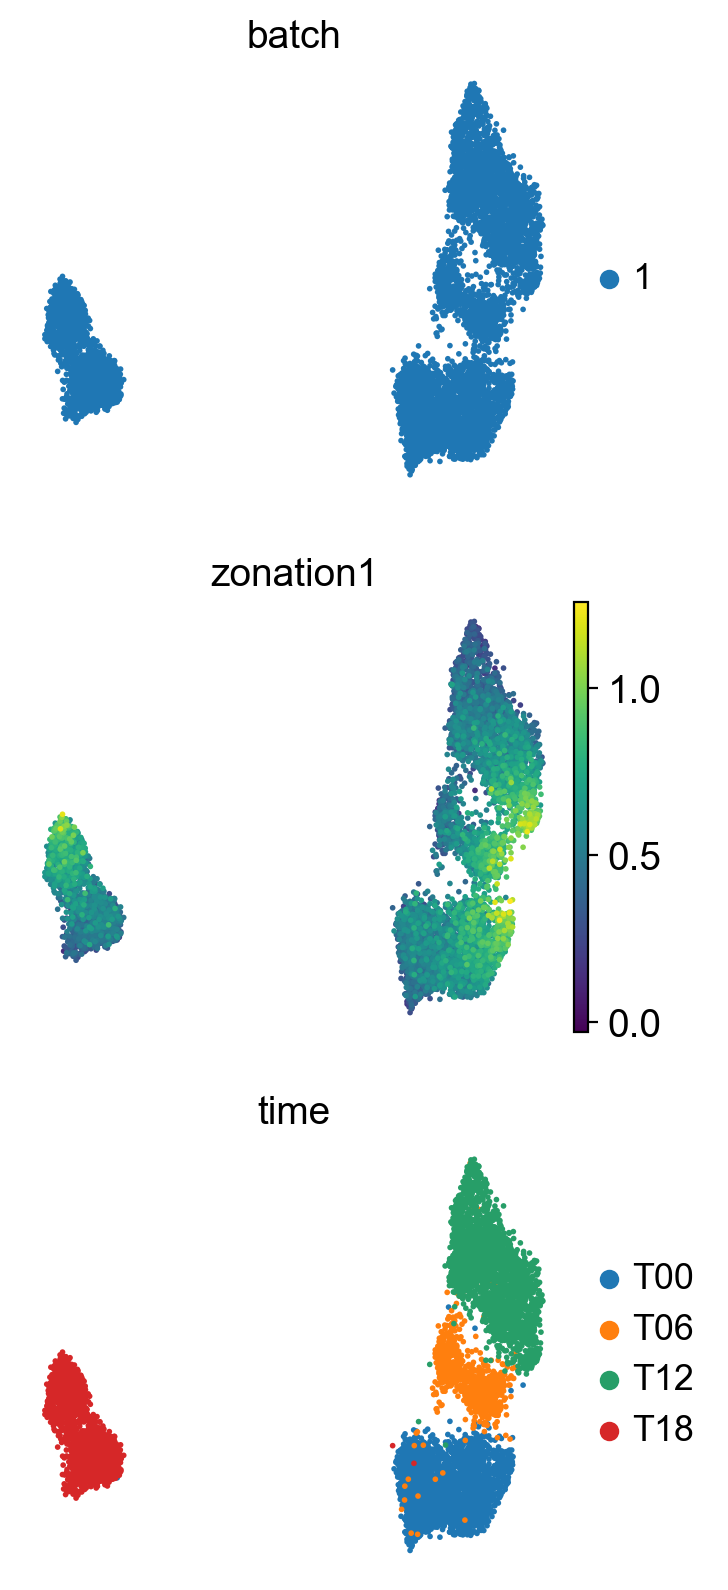

In [11]:
sc.pl.umap(adata, color=["batch", "zonation1", "time"], ncols=1, frameon=False)

### Train DRVI

In [12]:
# Setup data
DRVI.setup_anndata(
    adata,
    # DRVI accepts count data by default.
    # Do not forget to change gene_likelihood if you provide a non-count data.
    layer="counts",
    # Always provide a list. DRVI can accept multiple covariates.
    categorical_covariate_keys=["batch"],
    # DRVI accepts count data by default.
    # Set to false if you provide log-normalized data and use normal distribution (mse loss).
    is_count_data=True,
)

# construct the model
model = DRVI(
    adata,
    # Provide categorical covariates keys once again. Refer to advanced usages for more options.
    categorical_covariates=["batch"],
    n_latent=128,
    # For encoder and decoder dims, provide a list of integers.
    encoder_dims=[128, 128],
    decoder_dims=[128, 128],
)
model


INFO     DRVI: The model has been initialized                                                                      


DRVI 
Covariates: ['batch'], 
Latent size: 128, splits: 128, pooling of splits: 'logsumexp', 
Encoder dims: [128, 128], 
Decoder dims: [128, 128], 
Gene likelihood: pnb_softmax, 

Training status: Not Trained
Model's adata is minified?: False

In [ ]:
# For cpu training you should add the following line to the model.train parameters:
# accelerator="cpu", devices=1,
#
# For mps acceleration on macbooks, add the following line to the model.train parameters:
# accelerator="mps", devices=1,
#
# For gpu training don't provide any additional parameter.
# More details here: https://lightning.ai/docs/pytorch/stable/accelerators/gpu_basic.html

n_epochs = 400

# train the model
model.train(
    max_epochs=n_epochs,
    early_stopping=False,
    early_stopping_patience=20,
    # mps
    accelerator="mps", devices=1,
    # cpu
    # accelerator="cpu", devices=1,
    # gpu: no additional parameter
    #
    # No need to provide `plan_kwargs` if n_epochs >= 400.
    plan_kwargs={
        "n_epochs_kl_warmup": n_epochs,
    },
)

# Runtime:
# The runtime for CPU laptop (M1) is 208 minutes
# The runtime for Macbook gpu (M1) is 64 minutes
# The runtime for GPU (A100) is 17 minutes


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 14/400:   3%| | 13/400 [01:14<33:44,  5.23s/it, v_num=1, train_loss_step=2

In [ ]:
# Save the model
model.save("experiments/no_hvg_filters/drvi_general_pipeline_liver_simple_400_epochs", overwrite=True)

### Saving the Latent Space

In [ ]:
# Load the model
model = DRVI.load("experiments/no_hvg_filters/drvi_general_pipeline_liver_simple_400_epochs", adata)

In [ ]:
embed = ad.AnnData(model.get_latent_representation(), obs=adata.obs)
sc.pp.subsample(embed, fraction=1.0)  # Shuffling for better visualization of overlapping colors

sc.pp.neighbors(embed, n_neighbors=10, use_rep="X", n_pcs=embed.X.shape[1])
sc.tl.umap(embed, spread=1.0, min_dist=0.5, random_state=123)
sc.pp.pca(embed)

embed.write("experiments/no_hvg_filters/drvi_general_pipeline_liver_simple_400_epochs.h5ad")